#### Interpolating data files of Chruslinska & Nelemans

What we will be plotting is the total SFRD in a specific metallicity bin or the total SFR by summing the SFRD of each Z bin.
Data is taken from: https://ftp.science.ru.nl/astro/mchruslinska/

In [2]:
from __future__ import annotations
import logging
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from scipy.interpolate import interp1d, RegularGridInterpolator

# Type alias for float64 arrays
FloatArray = NDArray[np.float64]

# Functions are taken from Martyna's notebook, with some modifications.
def get_solar_metallicity_data() -> Dict[str, Tuple[float, float]]:
    """Return solar metallicity scales: {name: (Z_sun, 12+log(O/H))}"""
    return {
        "Asplund09": (0.0134, 8.69),
        "AndersGrevesse89": (0.017, 8.83),
        "GrevesseSauval98": (0.0201, 8.93),
        "Villante14": (0.019, 8.85),
    }

def foh_to_zz(foh: FloatArray | float, scale: str = "AndersGrevesse89") -> FloatArray | float:
    """Convert 12+log[O/H] to absolute metallicity mass fraction Z."""
    scales = get_solar_metallicity_data()
    if scale not in scales:
        raise ValueError(f"Scale '{scale}' invalid. Options: {list(scales.keys())}")
    
    z_sun, foh_sun = scales[scale]
    return 10 ** (np.log10(z_sun) + foh - foh_sun)


def zz_to_foh(zz: FloatArray | float, scale: str = "AndersGrevesse89") -> FloatArray | float:
    """Convert absolute metallicity mass fraction Z to 12+log[O/H]."""
    scales = get_solar_metallicity_data()
    if scale not in scales:
        raise ValueError(f"Scale '{scale}' invalid. Options: {list(scales.keys())}")
    
    z_sun, foh_sun = scales[scale]
    return np.log10(zz) - np.log10(z_sun) + foh_sun


def compute_sfrd_in_z_bins(
    sfrd_density: FloatArray,
    delt: FloatArray,
    z_bins: FloatArray,
    foh_min: float = 5.3,
    foh_max: float = 9.7,
) -> FloatArray:
    """
    Integrate SFRD density arrays into specific Z (metallicity) bins.

    Parameters
    ----------
    sfrd_density : FloatArray
        2D array of shape (N_redshift, N_foh) containing mass per unit volume.
    delt : FloatArray
        1D array of shape (N_redshift,) containing time bin widths in Myr.
    z_bins : FloatArray
        1D array containing the boundaries of the absolute metallicity bins.
    foh_min, foh_max : float
        Min and max of the FOH array axis in the data.

    Returns
    -------
    FloatArray
        Integrated SFRD per redshift per Z-bin, shape (N_redshift, len(z_bins)-1).
    """
    n_redshift, n_foh = sfrd_density.shape
    
    # Convert absolute mass into SFRD (M_sun / Mpc^3 / yr)
    sfrd_bins = sfrd_density / (1e6 * delt[:, None])
    
    # Cumulative integration along FOH
    sfrd_cdf = np.zeros((n_redshift, n_foh + 1), dtype=np.float64)
    sfrd_cdf[:, 1:] = np.cumsum(sfrd_bins, axis=1)
    
    dfoh = (foh_max - foh_min) / (n_foh - 1)
    foh_edges = np.linspace(foh_min - dfoh / 2, foh_max + dfoh / 2, n_foh + 1)
    
    # Map targeted Z bins back to FOH space and clip to array boundaries
    foh_eval_points = np.clip(zz_to_foh(z_bins), foh_edges[0], foh_edges[-1])
    
    # Vectorized interpolation along axis=1 across all redshifts simultaneously
    cdf_interp = interp1d(foh_edges, sfrd_cdf, axis=1, kind="linear")
    cdf_at_bins = cdf_interp(foh_eval_points)
    
    # Mass in bin is the difference between high and low CDF evaluations
    return cdf_at_bins[:, 1:] - cdf_at_bins[:, :-1]


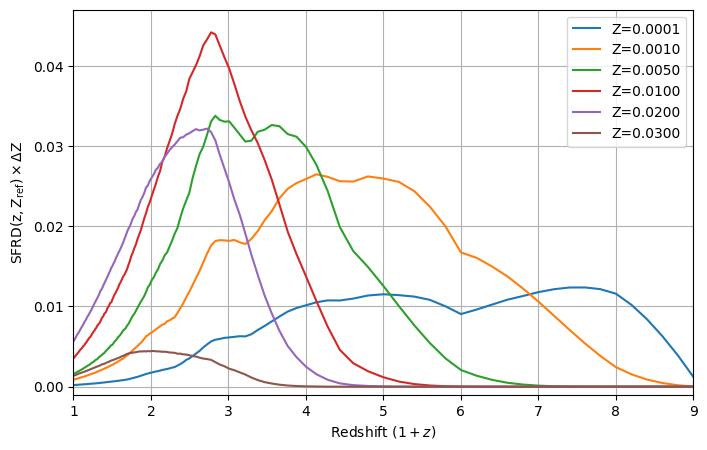

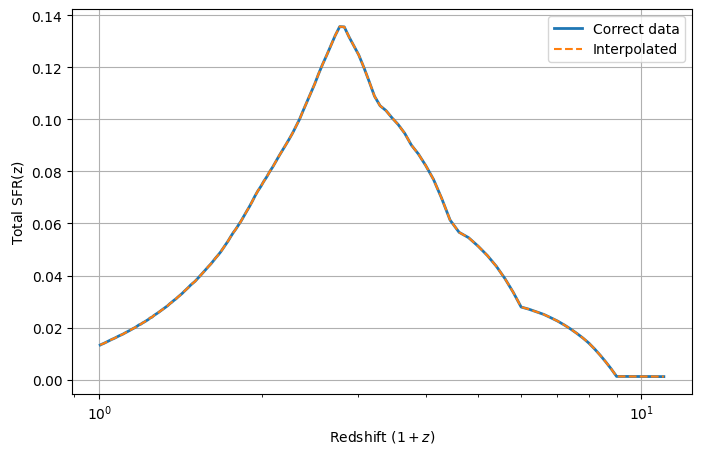

In [28]:
time, redshift_global, delt = np.loadtxt("metallicity_investigations/Time_redshift_deltaT.dat", unpack=True)
data = np.loadtxt("metallicity_investigations/moderate_FOH_z_dM.dat")


z_vals = np.array([0.0001, 0.001, 0.005, 0.01, 0.02, 0.03])
z_bins_edges = np.array([
    foh_to_zz(5.3 - 0.011), 0.0005, 0.003, 0.008, 0.015, 0.03, foh_to_zz(9.7 + 0.011)
])

sfrd_z_z = compute_sfrd_in_z_bins(data, delt, z_bins_edges)

z_data = np.flip(redshift_global)
sfrd_z_z_flipped = np.flip(sfrd_z_z, axis=0)

interp_func = RegularGridInterpolator((z_data, z_vals), sfrd_z_z_flipped)

z_eval = np.flip(redshift_global)
zz_eval_grid, z_vals_grid = np.meshgrid(z_eval, z_vals, indexing="ij")
eval_points = np.stack([zz_eval_grid.ravel(), z_vals_grid.ravel()], axis=-1)

psi = interp_func(eval_points).reshape(len(z_eval), len(z_vals))

plt.figure(figsize=(8, 5))
for i, z_val in enumerate(z_vals):
    plt.plot(1 + z_eval, psi[:, i], label=f"Z={z_val:.4f}")
    
plt.ylim([-0.001, 0.047])
plt.xlim([1, 9])
plt.legend()
plt.ylabel(r"$\rm SFRD(z, Z_{ref}) \times \Delta Z$") 
plt.xlabel(r"Redshift $(1+z)$")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(1 + z_data, np.sum(sfrd_z_z_flipped, axis=1), label="Correct data", lw=2)
plt.plot(1 + z_eval, np.sum(psi, axis=1), label="Interpolated", ls="--")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.ylabel(r"$\rm Total\ SFR(z)$") 
plt.xlabel(r"Redshift $(1+z)$")
plt.show()

The "correct" curve represent the directly summed SFR.

#### Comparing to data files of Hofman & Nelemans
These files are taken from https://github.com/SeppeStaelens/White_Dwarf_AGWB/tree/main/data/SFRD


In [29]:
import pandas as pd
key = "MZ19"
df = pd.read_csv(f'metallicity_investigations/{key}_SFRD_allbins.txt')
labels = np.flip(['$Z = 0.03$', '$Z=0.02$', '$Z=0.01$','$Z=0.005$','$Z=0.001$', '$Z=0.0001$'])
cmap = plt.get_cmap('autumn')
colors = cmap(np.linspace(0,1,len(labels)))
redshift = df['redshift']

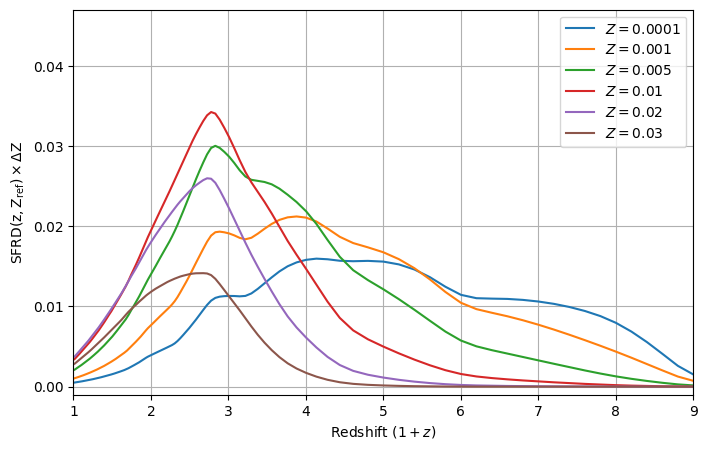

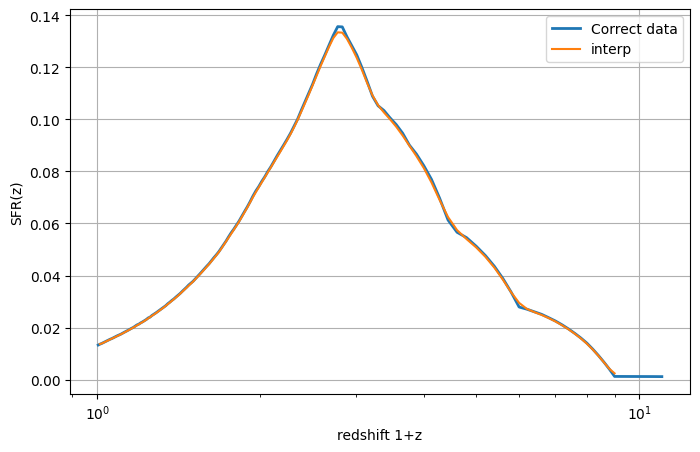

In [30]:
plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    data = df[f'{len(labels)-(i+1)}']
    plt.plot(1+redshift, data, label=label)
    
plt.ylim([-0.001, 0.047])
plt.xlim([1, 9])
plt.legend()
plt.ylabel(r"$\rm SFRD(z, Z_{ref}) \times \Delta Z$") 
plt.xlabel(r"Redshift $(1+z)$")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(1 + z_data, np.sum(sfrd_z_z_flipped, axis=1), label="Correct data", lw=2)
plt.plot(1+redshift, np.sum(np.array([df[f"{i}"] for i in range(len(labels))]), axis=0), label='interp')
plt.xscale("log")
plt.grid()
plt.legend()
plt.ylabel("SFR(z)") 
plt.xlabel("redshift 1+z")
plt.show()

already by eye you can see that the metallicity distributions are not the same, but the total SFRD is.
Also interesting is that the metallicity of the highest peak changes (in the first graph red was highest, now green is).

#### Naively summing the metallicities within the range of the Z bins

In [31]:
time, redshift_global, delt = np.asarray(np.loadtxt('metallicity_investigations/Time_redshift_deltaT.dat',unpack=True))
data = np.asarray(np.loadtxt('metallicity_investigations/moderate_FOH_z_dM.dat'))
sfrd_data = data / (1e6 * delt[:,None])
FOH_min, FOH_max = 5.3, 9.7
FOH_arr = np.linspace( FOH_min,FOH_max, 200)
dFOH=FOH_arr[1]-FOH_arr[0]

Z_arr_data = foh_to_zz(FOH_arr)

Z_vals = np.array([0.0001, 0.001, 0.005, 0.01, 0.02, 0.03])
Z_bins = np.array([foh_to_zz(FOH_min), 0.0005, 0.003, 0.008, 0.015, 0.03, foh_to_zz(FOH_max)])

FOH_bins = zz_to_foh(Z_bins)

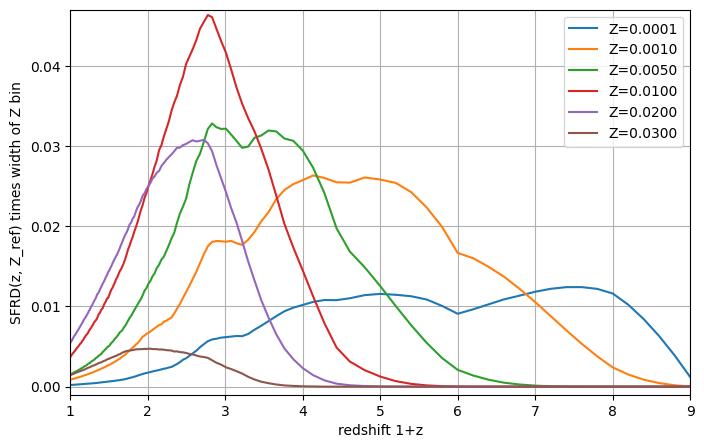

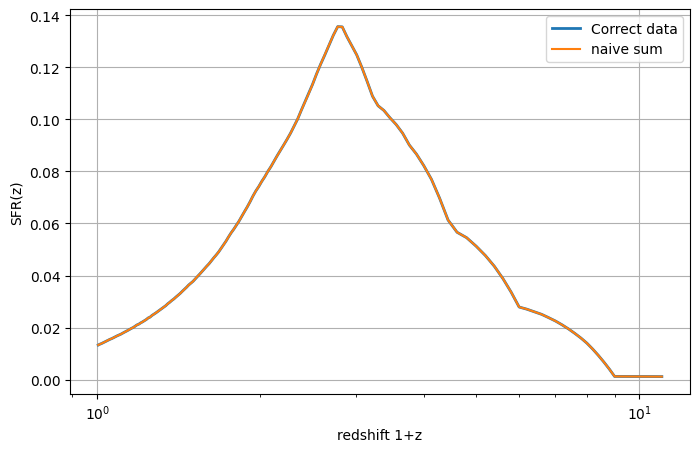

In [32]:
plt.figure(figsize=(8, 5))
data_zZ = np.zeros((len(redshift_global), len(Z_vals)))
for i, Z_val in enumerate(Z_vals):
    mask = (Z_arr_data >= Z_bins[i]) & (Z_arr_data < Z_bins[i+1])
    data = np.sum(sfrd_data[:, mask], axis=1)
    data_zZ[:,i] = data
    # bin_width = np.diff(Z_bins)[i]
    plt.plot(1+redshift_global, data, label=f"Z={Z_vals[i]:.4f}")
    
plt.ylim([-0.001, 0.047])
plt.xlim([1,9])
plt.legend()
plt.grid()
plt.ylabel("SFRD(z, Z_ref) times width of Z bin") 
plt.xlabel("redshift 1+z")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(1 + z_data, np.sum(sfrd_z_z_flipped, axis=1), label="Correct data", lw=2)
plt.plot(1+redshift_global, np.sum(data_zZ,axis=1), label='naive sum')
plt.xscale("log")
plt.grid()
plt.legend()
plt.ylabel("SFR(z)") 
plt.xlabel("redshift 1+z")
plt.show()

Also we can easily see that this gives similar results to the accurate interpolation and does not match the data from Hofman and Nelemans

In [34]:
from __future__ import annotations
import logging
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from scipy.interpolate import interp1d, RegularGridInterpolator

# Type alias for float64 arrays
FloatArray = NDArray[np.float64]


def get_solar_metallicity_data() -> Dict[str, Tuple[float, float]]:
    """Return solar metallicity scales: {name: (Z_sun, 12+log(O/H))}"""
    return {
        "Asplund09": (0.0134, 8.69),
        "AndersGrevesse89": (0.017, 8.83),
        "GrevesseSauval98": (0.0201, 8.93),
        "Villante14": (0.019, 8.85),
    }


def foh_to_zz(foh: FloatArray | float, scale: str = "AndersGrevesse89") -> FloatArray | float:
    """Convert 12+log[O/H] to absolute metallicity mass fraction Z."""
    scales = get_solar_metallicity_data()
    if scale not in scales:
        raise ValueError(f"Scale '{scale}' invalid. Options: {list(scales.keys())}")
    
    z_sun, foh_sun = scales[scale]
    return 10 ** (np.log10(z_sun) + foh - foh_sun)


def zz_to_foh(zz: FloatArray | float, scale: str = "AndersGrevesse89") -> FloatArray | float:
    """Convert absolute metallicity mass fraction Z to 12+log[O/H]."""
    scales = get_solar_metallicity_data()
    if scale not in scales:
        raise ValueError(f"Scale '{scale}' invalid. Options: {list(scales.keys())}")
    
    z_sun, foh_sun = scales[scale]
    return np.log10(zz) - np.log10(z_sun) + foh_sun


def compute_sfrd_in_z_bins(
    sfrd_density: FloatArray,
    delt: FloatArray,
    z_bins: FloatArray,
    foh_min: float = 5.3,
    foh_max: float = 9.7,
) -> FloatArray:
    """
    Integrate SFRD density arrays into specific Z (metallicity) bins.

    Parameters
    ----------
    sfrd_density : FloatArray
        2D array of shape (N_redshift, N_foh) containing mass per unit volume.
    delt : FloatArray
        1D array of shape (N_redshift,) containing time bin widths in Myr.
    z_bins : FloatArray
        1D array containing the boundaries of the absolute metallicity bins.
    foh_min, foh_max : float
        Min and max of the FOH array axis in the data.

    Returns
    -------
    FloatArray
        Integrated SFRD per redshift per Z-bin, shape (N_redshift, len(z_bins)-1).
    """
    n_redshift, n_foh = sfrd_density.shape
    
    # Convert absolute mass into SFRD (M_sun / Mpc^3 / yr)
    sfrd_bins = sfrd_density / (1e6 * delt[:, None])
    
    # Cumulative integration along FOH
    sfrd_cdf = np.zeros((n_redshift, n_foh + 1), dtype=np.float64)
    sfrd_cdf[:, 1:] = np.cumsum(sfrd_bins, axis=1)
    
    # Define actual bin edges assuming the 200 points represent bin centers.
    # This prevents the "dropped first bin" issue found in the original snippet.
    dfoh = (foh_max - foh_min) / (n_foh - 1)
    foh_edges = np.linspace(foh_min - dfoh / 2, foh_max + dfoh / 2, n_foh + 1)
    
    # Map targeted Z bins back to FOH space and clip to array boundaries
    foh_eval_points = np.clip(zz_to_foh(z_bins), foh_edges[0], foh_edges[-1])
    
    # Vectorized interpolation along axis=1 across all redshifts simultaneously
    cdf_interp = interp1d(foh_edges, sfrd_cdf, axis=1, kind="linear")
    cdf_at_bins = cdf_interp(foh_eval_points)
    
    # Mass in bin is the difference between high and low CDF evaluations
    return cdf_at_bins[:, 1:] - cdf_at_bins[:, :-1]



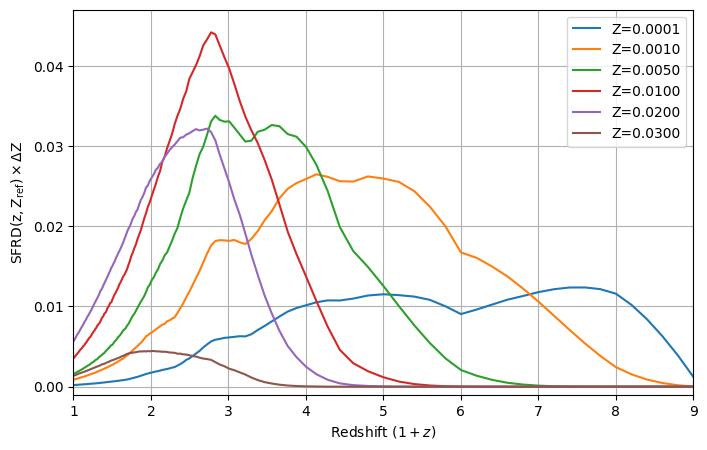

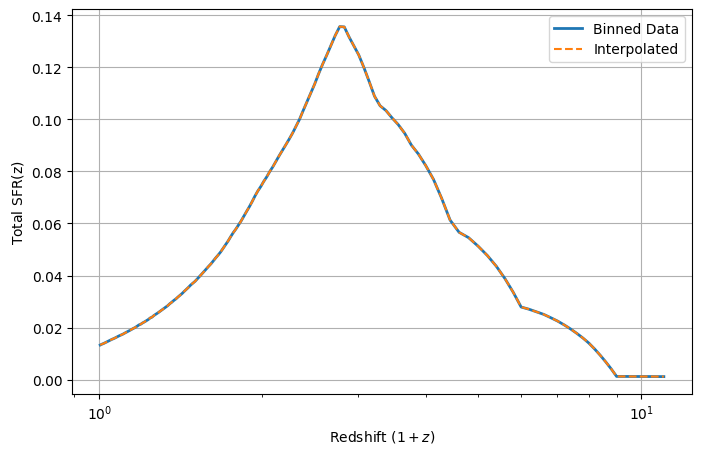

In [35]:
time, redshift_global, delt = np.loadtxt("Time_redshift_deltaT.dat", unpack=True)
data = np.loadtxt("moderate_FOH_z_dM.dat")


z_vals = np.array([0.0001, 0.001, 0.005, 0.01, 0.02, 0.03])
z_bins_edges = np.array([
    foh_to_zz(5.3 - 0.011), 0.0005, 0.003, 0.008, 0.015, 0.03, foh_to_zz(9.7 + 0.011)
])

sfrd_z_z = compute_sfrd_in_z_bins(data, delt, z_bins_edges)

z_data = np.flip(redshift_global)
sfrd_z_z_flipped = np.flip(sfrd_z_z, axis=0)

interp_func = RegularGridInterpolator((z_data, z_vals), sfrd_z_z_flipped)

z_eval = np.flip(redshift_global)
zz_eval_grid, z_vals_grid = np.meshgrid(z_eval, z_vals, indexing="ij")
eval_points = np.stack([zz_eval_grid.ravel(), z_vals_grid.ravel()], axis=-1)

psi = interp_func(eval_points).reshape(len(z_eval), len(z_vals))

# 5. Plotting (Z-bins)
plt.figure(figsize=(8, 5))
for i, z_val in enumerate(z_vals):
    plt.plot(1 + z_eval, psi[:, i], label=f"Z={z_val:.4f}")
    
plt.ylim([-0.001, 0.047])
plt.xlim([1, 9])
plt.legend()
plt.ylabel(r"$\rm SFRD(z, Z_{ref}) \times \Delta Z$") 
plt.xlabel(r"Redshift $(1+z)$")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(1 + z_data, np.sum(sfrd_z_z_flipped, axis=1), label="Binned Data", lw=2)
plt.plot(1 + z_eval, np.sum(psi, axis=1), label="Interpolated", ls="--")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.ylabel(r"$\rm Total\ SFR(z)$") 
plt.xlabel(r"Redshift $(1+z)$")
plt.show()